# LabChart Parser walkthrough

Interactive tour of the `labchart_parser` API using the sample export
bundled with the project.

## Imports and configuration
We load the parser, point to the example data file, and ensure plots render inline.

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from labchart_parser import LabChartFile

data_path = Path('examples/data/labchart_file.example.txt')
data_path

PosixPath('examples/data/labchart_file.example.txt')

## Load the export
Create the convenience wrapper `LabChartFile` and inspect metadata, channels, and available blocks.

In [2]:
lc = LabChartFile.from_file(str(data_path))

metadata = pd.Series(lc.metadata)
metadata

Interval                                                    0.01 s
ExcelDateTime     4.5855649139942347e+04\t07/17/25 15:34:45.691019
TimeFormat                                            StartOfBlock
DateFormat                                                        
UnitName                            [*, , *, cmH2O, *, *, *, *, *]
Interval_s                                                    0.01
blocks           [{'Interval': '0.01 s', 'ExcelDateTime': '4.58...
dtype: object

In [3]:
lc.channels

['PushSWE',
 'Flow',
 'EMG',
 'Pressure',
 'Flow BIS',
 'Inspi cyclic',
 'Expi cyclic',
 'L/m -> L/s',
 'VolumeResp']

In [4]:
print("number of blocks:", len(lc.blocks))

number of blocks: 6


## Comments overview
Display the first few annotated comments captured by the parser.

In [5]:
lc.comments.head()

,Time,time_block,time_abs,block,Comment
0,2.43,1.93,1.93,1,INSPI
1,2.69,2.19,2.19,1,Dia1
2,2.91,2.41,2.41,1,EXPI
3,4.74,4.24,4.24,1,INSPI
4,5.22,4.72,4.72,1,EXPI


### Filter comments
Exclude specific annotation labels using the helper introduced in the core API.

In [11]:
exclude_values = ['INSPI', 'EXPI']
lc.get_block_comments_excluding(block=1, exclude_values=exclude_values)[0]

'Dia1'

## Block data
Slice the first block to work with a tidy dataframe that includes time bases and comments.

In [7]:
df_block1 = lc.get_block_df(1)
df_block1.head()

,Time,time_block,time_abs,Comment,PushSWE,Flow,EMG,Pressure,Flow BIS,Inspi cyclic,Expi cyclic,L/m -> L/s,VolumeResp
0,0.50,0.00,0.00,None,3.202508,-42.38833,0.647656,24.43683,-42.38833,1.469056e-08,1.469056e-08,-0.706472,-0.003621
1,0.51,0.01,0.01,None,3.202531,-42.37696,0.103516,24.43413,-42.37696,1.469056e-08,1.469056e-08,-0.706283,-0.010684
2,0.52,0.02,0.02,None,3.202563,-42.37696,0.643594,24.43413,-42.37696,1.469056e-08,1.469056e-08,-0.706283,-0.017747
3,0.53,0.03,0.03,None,3.202594,-42.37696,0.083906,24.43413,-42.37696,1.469056e-08,1.469056e-08,-0.706283,-0.024810
4,0.54,0.04,0.04,None,3.202609,-42.37696,0.611250,24.43413,-42.37696,1.469056e-08,1.469056e-08,-0.706283,-0.031873


## Plot a channel
Visualise signals using the built-in `plot_channel()` method or manually with matplotlib.

<Axes: title={'center': 'Flow – Block 1'}, xlabel='Time in block (s)', ylabel='Flow'>

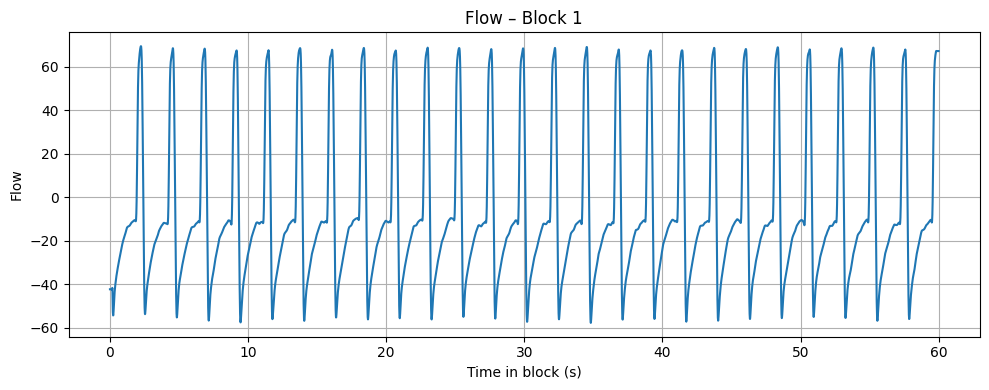

In [8]:
# Quick plot using the built-in method
lc.plot_channel('Flow', block=1)

<Axes: title={'center': 'Pressure – Block 1'}, xlabel='Time in block (s)', ylabel='Pressure'>

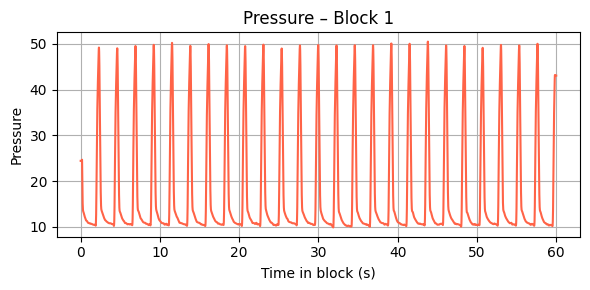

In [9]:
# Plot Pressure with custom styling
lc.plot_channel('Pressure', block=1, color='tomato', figsize=(6, 3))

### Multiple channels in subplots
Use the `ax` parameter to combine multiple channels in a single figure.

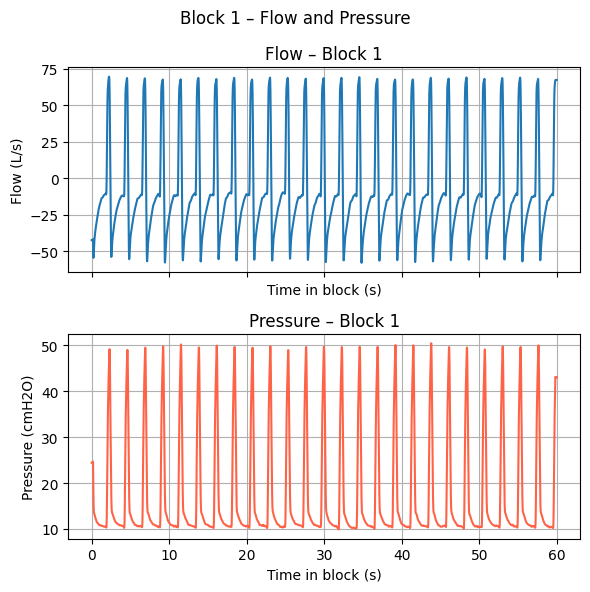

In [10]:
# Combine multiple channels in subplots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(6, 6), sharex=True)

lc.plot_channel('Flow', block=1, ax=ax1, ylabel='Flow (L/s)')
lc.plot_channel('Pressure', block=1, ax=ax2, color='tomato', ylabel='Pressure (cmH2O)')

fig.suptitle('Block 1 – Flow and Pressure', fontsize=12)
fig.tight_layout()